# Shrimp Water-Quality Detection and Forecasting Model

This notebook implements two modules:

1. **Random Forest risk-condition classifier** — classifies the current environmental condition as **Low, Moderate, or High Risk**.
2. **ARIMA forecasting module** — produces short-term forecasts for **DO, pH, Temperature, and Salinity**, then converts the forecasts into projected risk conditions.

### Important methodological note
The uploaded dataset contains water-quality measurements but **does not contain an observed shrimp-mortality outcome**. Therefore, the Random Forest target is an **environmental risk-condition label derived from the supplied Healthy / Conditional / Unhealthy thresholds**. It should not be described as a validated biological mortality predictor unless actual shrimp mortality/event labels are later added.

The composite risk score used here is transparent and configurable:

- Healthy parameter = 0 points
- Conditional parameter = 1 point
- Unhealthy parameter = 2 points
- **Low Risk:** total score 0–1
- **Moderate Risk:** total score 2–3
- **High Risk:** total score 4 or more

This operational rule can be revised if the research protocol defines a different risk aggregation scheme.


In [1]:
# 1. Install packages if needed
# Run this cell once in the VSCode terminal/notebook environment:
# %pip install pandas numpy matplotlib scikit-learn statsmodels openpyxl joblib

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
)
import joblib

from statsmodels.tsa.arima.model import ARIMA

print("Libraries loaded.")


Libraries loaded.


## 2. Define the research thresholds

These values are taken directly from the supplied category table.

In [2]:
# Health-status thresholds supplied by the project

PARAMETERS = {
    "DO (mg/L)": {
        "healthy": lambda x: x >= 5.0,
        "conditional": lambda x: 3.7 <= x < 5.0,
    },
    "pH": {
        "healthy": lambda x: 7.5 <= x <= 8.5,
        "conditional": lambda x: 6.5 <= x < 7.5 or 8.5 < x <= 9.0,
    },
    "Temp (OC)": {
        "healthy": lambda x: 26.0 <= x <= 30.0,
        "conditional": lambda x: 25.0 <= x < 26.0 or 30.0 < x <= 31.0,
    },
    "Salinity (ppt)": {
        "healthy": lambda x: 15.0 <= x <= 25.0,
        "conditional": lambda x: 10.0 <= x < 15.0 or 25.0 < x <= 30.0,
    },
}

PARAM_COLS = list(PARAMETERS.keys())

# Quality-control setting.
# Values above this are treated as invalid sensor readings for modeling.
# The threshold is NOT a biological mortality threshold.
DO_SENSOR_MAX = 20.0

RISK_LABELS = {0: "Low", 1: "Moderate", 2: "High"}

print(PARAM_COLS)


['DO (mg/L)', 'pH', 'Temp (OC)', 'Salinity (ppt)']


## 3. Load and clean the Excel dataset

The workbook has one sheet per nominal year. The notebook uses the **actual Date/Time values** rather than blindly trusting the sheet name.

During inspection, the workbook contains:
- some missing values,
- a small number of duplicate timestamps,
- records dated **2013 in the 2023 sheet**, and
- records dated **2026 in the 2025 sheet**.

For a 2021–2025 study scope, those out-of-scope dates are excluded. The raw workbook is never modified.

Several DO values are also extremely high for a column labeled mg/L. Those values are treated as sensor/data-quality anomalies (`DO > 20 mg/L`) and converted to missing values before modeling. This is a QC decision, not a mortality criterion.


In [3]:
# Locate the workbook.
# Put the Excel file in the same folder as this notebook, or in ../data/.

candidate_paths = [
    Path("MLDATASET - cleaned.xlsx"),
    Path("../data/MLDATASET - cleaned.xlsx"),
    Path("/mnt/data/MLDATASET - cleaned.xlsx"),  # optional when running in this environment
]

DATA_PATH = next((p for p in candidate_paths if p.exists()), None)

if DATA_PATH is None:
    raise FileNotFoundError(
        "Could not find 'MLDATASET - cleaned.xlsx'. "
        "Place it beside the notebook or inside ../data/."
    )

print("Using:", DATA_PATH.resolve())

excel = pd.ExcelFile(DATA_PATH)
print("Sheets:", excel.sheet_names)

frames = []
for sheet in excel.sheet_names:
    temp = pd.read_excel(DATA_PATH, sheet_name=sheet)
    temp["source_sheet"] = sheet
    frames.append(temp)

raw = pd.concat(frames, ignore_index=True)

# Standardize numeric columns because some sheets contain numbers stored as text.
for col in PARAM_COLS:
    raw[col] = pd.to_numeric(raw[col], errors="coerce")

# Build a real timestamp.
raw["datetime"] = pd.to_datetime(
    raw["Date"].astype(str) + " " + raw["Time"].astype(str),
    errors="coerce"
)

# Keep the actual study period 2021–2025.
df = raw[
    raw["datetime"].dt.year.between(2021, 2025, inclusive="both")
].copy()

# Remove duplicate timestamps, keeping the first record.
df = df.drop_duplicates(subset="datetime").sort_values("datetime").reset_index(drop=True)

# Quality control: suspicious DO sensor values.
df.loc[df["DO (mg/L)"] > DO_SENSOR_MAX, "DO (mg/L)"] = np.nan

print(f"Raw rows: {len(raw):,}")
print(f"Rows in 2021–2025 scope: {len(df):,}")
print("\nMissing values after QC:")
print(df[PARAM_COLS].isna().sum())
print("\nDate range:")
print(df["datetime"].min(), "to", df["datetime"].max())


Using: C:\Users\USER\Desktop\Mortality-Prediction-for-Penaeus-vannamei\MLDATASET - cleaned.xlsx
Sheets: ['2021', '2022', '2023', '2024', '2025']
Raw rows: 3,205
Rows in 2021–2025 scope: 3,019

Missing values after QC:
DO (mg/L)         41
pH                15
Temp (OC)          2
Salinity (ppt)     1
dtype: int64

Date range:
2021-01-27 09:43:34 to 2025-12-15 11:26:00


,DO (mg/L),pH,Temp (OC),Salinity (ppt)
count,2978.000,3004.000,3017.000,3018.000
mean,6.582,8.005,31.576,29.160
std,1.801,0.448,2.567,15.041
min,0.000,5.540,20.100,0.000
25%,5.670,7.740,29.900,23.200
50%,6.450,7.970,31.300,32.620
75%,7.278,8.190,33.100,39.760
max,18.270,10.180,41.500,71.110


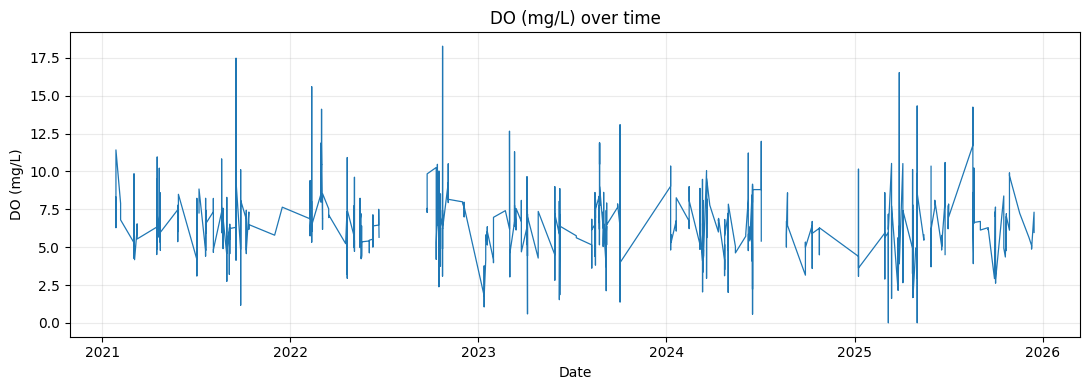

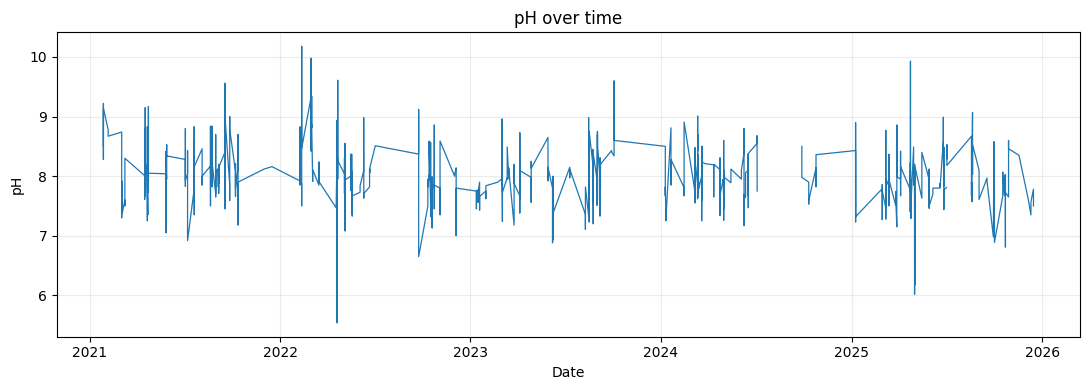

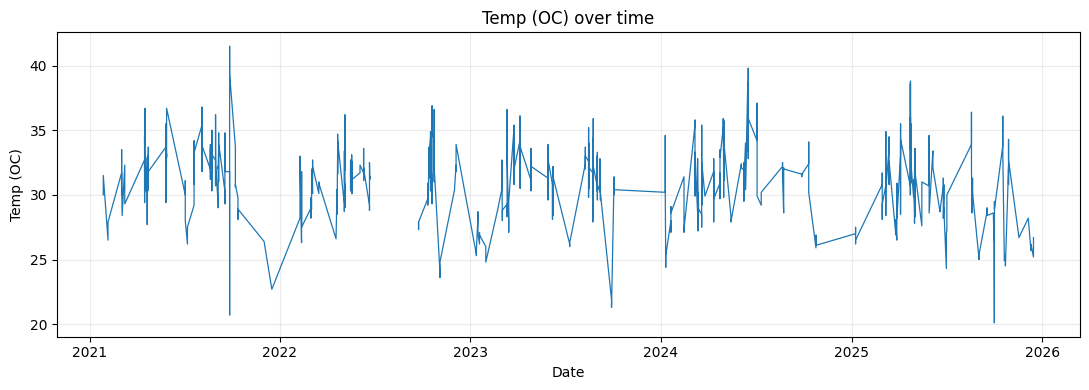

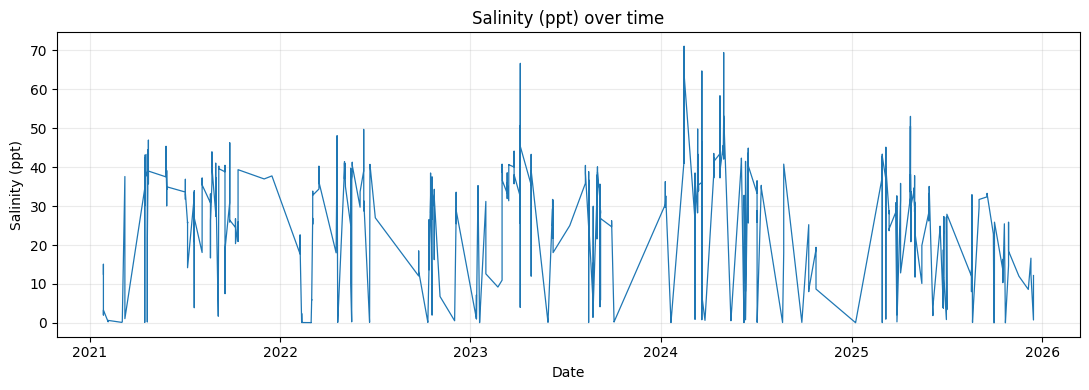

In [4]:
# Basic descriptive statistics after date filtering and DO QC
display(df[PARAM_COLS].describe().round(3))

# Visualize the four monitored parameters
for col in PARAM_COLS:
    plt.figure(figsize=(11, 4))
    plt.plot(df["datetime"], df[col], linewidth=0.9)
    plt.title(f"{col} over time")
    plt.xlabel("Date")
    plt.ylabel(col)
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()


## 4. Convert the supplied parameter categories into model features

Each measurement is assigned a parameter condition:

- `0 = Healthy`
- `1 = Conditional`
- `2 = Unhealthy`

The four parameter scores are summed to produce the operational risk score used as the Random Forest target.

In [5]:
def parameter_status(value, parameter):
    if pd.isna(value):
        return np.nan
    rules = PARAMETERS[parameter]
    if rules["healthy"](value):
        return 0
    if rules["conditional"](value):
        return 1
    return 2

for col in PARAM_COLS:
    df[col + " status"] = df[col].apply(lambda x, c=col: parameter_status(x, c))

status_cols = [c + " status" for c in PARAM_COLS]

# Complete cases are required for the composite label.
model_df = df.dropna(subset=PARAM_COLS).copy()

model_df["risk_score"] = model_df[status_cols].sum(axis=1)

model_df["risk"] = np.select(
    [
        model_df["risk_score"].between(0, 1),
        model_df["risk_score"].between(2, 3),
        model_df["risk_score"] >= 4,
    ],
    ["Low", "Moderate", "High"],
    default="Unknown",
)

print("Risk distribution:")
print(model_df["risk"].value_counts())
print("\nRisk percentages:")
print((model_df["risk"].value_counts(normalize=True) * 100).round(2))


Risk distribution:
risk
High        1589
Moderate    1221
Low          160
Name: count, dtype: int64

Risk percentages:
risk
High        53.50
Moderate    41.11
Low          5.39
Name: proportion, dtype: float64


In [6]:
# Inspect a sample of the generated labels
display(
    model_df[
        ["datetime"] + PARAM_COLS + status_cols + ["risk_score", "risk"]
    ].head(15)
)


,datetime,DO (mg/L),pH,Temp (OC),Salinity (ppt),DO (mg/L) status,pH status,Temp (OC) status,Salinity (ppt) status,risk_score,risk
0,2021-01-27 09:43:34,8.30,8.50,30.0,12.52,0.0,0.0,0.0,1.0,1.0,Low
1,2021-01-27 09:45:22,8.18,8.64,30.0,15.10,0.0,1.0,0.0,0.0,1.0,Low
2,2021-01-27 09:47:36,7.51,8.54,30.4,14.59,0.0,1.0,1.0,1.0,3.0,Moderate
3,2021-01-27 09:51:11,7.85,8.68,30.5,14.93,0.0,1.0,1.0,1.0,3.0,Moderate
4,2021-01-27 09:54:26,8.22,8.60,30.8,15.04,0.0,1.0,1.0,0.0,2.0,Moderate
5,2021-01-27 09:56:53,8.41,8.60,30.9,15.04,0.0,1.0,1.0,0.0,2.0,Moderate
6,2021-01-27 09:58:58,8.72,8.64,31.2,15.02,0.0,1.0,2.0,0.0,3.0,Moderate
7,2021-01-27 10:03:26,6.28,8.28,30.1,8.69,0.0,0.0,1.0,2.0,3.0,Moderate
8,2021-01-27 10:05:52,7.96,9.22,30.4,1.98,0.0,2.0,1.0,2.0,5.0,High
9,2021-01-27 10:11:29,11.42,9.14,31.5,3.29,0.0,2.0,2.0,2.0,6.0,High


## 5. Random Forest detection/classification model

### Modeling strategy
A chronological split is used instead of a random split because this is time-dependent monitoring data.

- First 80% of observations → training
- Last 20% → testing

The model uses the four current water-quality measurements plus simple time features. The target is the operational Low/Moderate/High environmental-risk class.

**Interpretation:** a high test score means the Random Forest can reproduce the supplied threshold-based risk scheme. It does **not** establish that the model predicts actual shrimp mortality, because no mortality labels are present in the dataset.


In [7]:
# Feature engineering for the detection module
clf_df = model_df.copy()

clf_df["hour"] = clf_df["datetime"].dt.hour + clf_df["datetime"].dt.minute / 60
clf_df["month"] = clf_df["datetime"].dt.month

# Cyclic encoding for time-of-day and month
clf_df["hour_sin"] = np.sin(2 * np.pi * clf_df["hour"] / 24)
clf_df["hour_cos"] = np.cos(2 * np.pi * clf_df["hour"] / 24)
clf_df["month_sin"] = np.sin(2 * np.pi * clf_df["month"] / 12)
clf_df["month_cos"] = np.cos(2 * np.pi * clf_df["month"] / 12)

FEATURES = PARAM_COLS + [
    "hour_sin", "hour_cos", "month_sin", "month_cos"
]

clf_df = clf_df.sort_values("datetime").reset_index(drop=True)

split_idx = int(len(clf_df) * 0.80)

train_df = clf_df.iloc[:split_idx].copy()
test_df = clf_df.iloc[split_idx:].copy()

X_train = train_df[FEATURES]
y_train = train_df["risk"]

X_test = test_df[FEATURES]
y_test = test_df["risk"]

rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=2,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1,
)

rf.fit(X_train, y_train)

pred = rf.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, pred), 4))
print("Balanced accuracy:", round(balanced_accuracy_score(y_test, pred), 4))
print("Macro F1:", round(f1_score(y_test, pred, average="macro"), 4))

print("\nClassification report:")
print(classification_report(y_test, pred, labels=["Low", "Moderate", "High"], zero_division=0))


Accuracy: 0.8586
Balanced accuracy: 0.8187
Macro F1: 0.8452

Classification report:
              precision    recall  f1-score   support

         Low       0.94      0.71      0.81        65
    Moderate       0.78      0.97      0.86       273
        High       0.97      0.78      0.87       256

    accuracy                           0.86       594
   macro avg       0.90      0.82      0.85       594
weighted avg       0.88      0.86      0.86       594



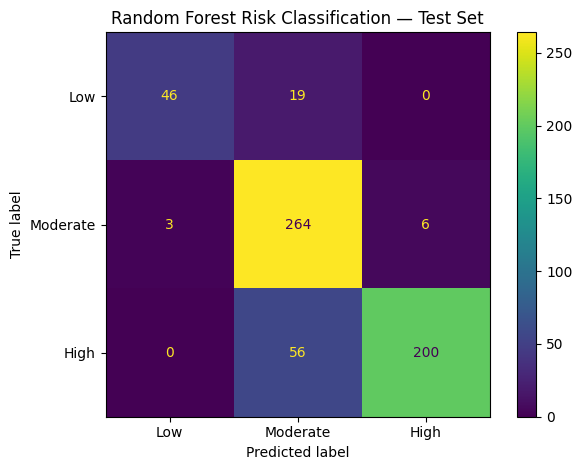

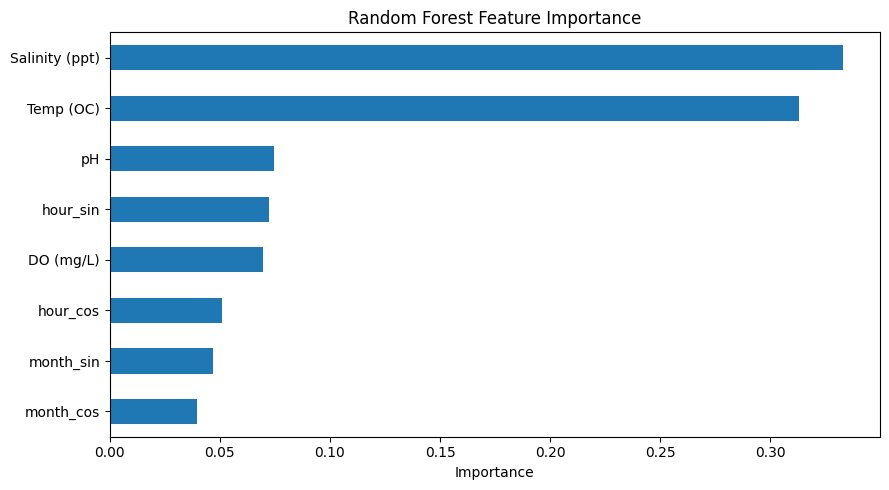

,importance
Salinity (ppt),0.3332
Temp (OC),0.3129
pH,0.0745
hour_sin,0.0723
DO (mg/L),0.0695
hour_cos,0.0509
month_sin,0.0470
month_cos,0.0398


In [8]:
# Confusion matrix
cm = confusion_matrix(y_test, pred, labels=["Low", "Moderate", "High"])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Low", "Moderate", "High"]
)
disp.plot()
plt.title("Random Forest Risk Classification — Test Set")
plt.tight_layout()
plt.show()

# Feature importance
importance = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=False)

plt.figure(figsize=(9, 5))
importance.sort_values().plot(kind="barh")
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

display(importance.to_frame("importance").round(4))


## 6. Risk-detection function for the application

This function is the part that can later be connected to the monitoring system.

Input:
`Temperature, DO, Salinity, pH`

Output:
- predicted risk,
- class probabilities,
- parameter-level condition status,
- composite rule score.

The Random Forest prediction is accompanied by the rule-based status so that the system remains explainable.


In [9]:
def detect_risk(temp, do, salinity, ph):
    values = {
        "Temp (OC)": temp,
        "DO (mg/L)": do,
        "Salinity (ppt)": salinity,
        "pH": ph,
    }

    x = pd.DataFrame([values])

    # Match the feature engineering used during training.
    # For an API/system implementation, pass the actual timestamp instead.
    now = pd.Timestamp.now()
    hour = now.hour + now.minute / 60
    month = now.month

    x["hour_sin"] = np.sin(2 * np.pi * hour / 24)
    x["hour_cos"] = np.cos(2 * np.pi * hour / 24)
    x["month_sin"] = np.sin(2 * np.pi * month / 12)
    x["month_cos"] = np.cos(2 * np.pi * month / 12)

    prediction = rf.predict(x[FEATURES])[0]
    probabilities = dict(zip(rf.classes_, rf.predict_proba(x[FEATURES])[0]))

    statuses = {
        p: parameter_status(values[p], p)
        for p in PARAM_COLS
    }

    score = sum(v for v in statuses.values() if pd.notna(v))
    rule_risk = (
        "Low" if score <= 1 else
        "Moderate" if score <= 3 else
        "High"
    )

    return {
        "random_forest_prediction": prediction,
        "probabilities": probabilities,
        "parameter_status": statuses,
        "rule_based_risk": rule_risk,
        "risk_score": int(score),
    }

# Example
example = detect_risk(
    temp=30.0,
    do=4.2,
    salinity=28.0,
    ph=8.2,
)
example


{'random_forest_prediction': 'Moderate',
 'probabilities': {'High': np.float64(0.249239173365793),
  'Low': np.float64(0.2076732293894851),
  'Moderate': np.float64(0.5430875972447218)},
 'parameter_status': {'DO (mg/L)': 1,
  'pH': 0,
  'Temp (OC)': 0,
  'Salinity (ppt)': 1},
 'rule_based_risk': 'Moderate',
 'risk_score': 2}

## 7. Prepare the time series for ARIMA

The raw observations are sampled at irregular intervals and in bursts. ARIMA assumes an ordered, regularly spaced series. To avoid treating every individual reading as an equally spaced time point, the notebook aggregates measurements by **sampling date using the daily median**.

Because the dataset has gaps between sampling dates, the resulting ARIMA forecast should be described as a forecast of the **next monitoring periods/sampling days**, not as a guaranteed calendar-day forecast.

The notebook forecasts each parameter separately.


In [10]:
# Daily median time series
daily = (
    model_df.set_index("datetime")[PARAM_COLS]
    .resample("D")
    .median()
    .dropna(how="all")
)

# Only retain days with complete daily medians for all four parameters.
daily = daily.dropna(subset=PARAM_COLS)

print("Number of observed sampling days:", len(daily))
print("Date range:", daily.index.min(), "to", daily.index.max())

display(daily.head())


Number of observed sampling days: 142
Date range: 2021-01-27 00:00:00 to 2025-12-15 00:00:00


,DO (mg/L),pH,Temp (OC),Salinity (ppt)
datetime,,,,
2021-01-27,8.200,8.620,30.45,14.760
2021-02-05,7.345,8.725,27.20,0.455
2021-03-03,7.260,8.000,31.20,0.130
2021-03-04,4.170,7.380,28.40,0.240
2021-03-09,6.350,8.100,30.40,36.740


## 8. Select ARIMA order by AIC

The search is intentionally small because only about 140 daily sampling points are available. The selected order can be inspected for each parameter.

If the research protocol has already established an ARIMA order (for example, ARIMA(1,1,1)), replace the automatic selection with that fixed order and report the basis for the selection in the methodology chapter.


In [11]:
def select_arima_order(series, p_values=(0, 1, 2), d_values=(0, 1), q_values=(0, 1, 2)):
    series = series.reset_index(drop=True)
    results = []

    for p in p_values:
        for d in d_values:
            for q in q_values:
                try:
                    model = ARIMA(
                        series,
                        order=(p, d, q),
                        enforce_stationarity=False,
                        enforce_invertibility=False,
                    ).fit()

                    results.append({
                        "order": (p, d, q),
                        "aic": model.aic,
                    })
                except Exception:
                    pass

    if not results:
        raise RuntimeError("No ARIMA model could be fitted.")

    results_df = pd.DataFrame(results).sort_values("aic").reset_index(drop=True)
    return tuple(results_df.iloc[0]["order"]), results_df


orders = {}

for col in PARAM_COLS:
    best_order, search_results = select_arima_order(daily[col])
    orders[col] = best_order

    print(f"\n{col}: best order = ARIMA{best_order}")
    display(search_results.head(5).round(2))



DO (mg/L): best order = ARIMA(0, 0, 2)


,order,aic
0,"(0, 0, 2)",502.88
1,"(2, 1, 2)",502.89
2,"(1, 0, 2)",502.93
3,"(0, 1, 2)",504.88
4,"(2, 0, 2)",504.93



pH: best order = ARIMA(0, 1, 2)


,order,aic
0,"(0, 1, 2)",77.27
1,"(0, 0, 2)",77.94
2,"(2, 1, 2)",78.11
3,"(1, 1, 2)",78.19
4,"(2, 0, 0)",78.62



Temp (OC): best order = ARIMA(1, 1, 2)


,order,aic
0,"(1, 1, 2)",681.15
1,"(0, 1, 2)",681.23
2,"(2, 1, 2)",682.61
3,"(2, 0, 2)",685.53
4,"(0, 0, 2)",685.98



Salinity (ppt): best order = ARIMA(1, 1, 2)


,order,aic
0,"(1, 1, 2)",1147.56
1,"(0, 1, 2)",1148.81
2,"(2, 1, 2)",1149.40
3,"(0, 0, 2)",1150.69
4,"(1, 0, 2)",1151.86


## 9. Time-series holdout validation

The last 14 observed sampling days are held out for validation. This estimates how well each ARIMA model forecasts unseen observations.

Metrics:
- MAE
- RMSE

After validation, each model is refit on the complete series before producing the final short-term forecast.


In [12]:
def fit_and_validate_arima(series, order, holdout=14):
    # ARIMA receives an equally spaced observation sequence.
    # The original calendar dates are retained separately for reporting.
    y = series.reset_index(drop=True)

    train = y.iloc[:-holdout]
    test = y.iloc[-holdout:]

    model = ARIMA(
        train,
        order=order,
        enforce_stationarity=False,
        enforce_invertibility=False,
    ).fit()

    forecast = model.forecast(steps=holdout)

    mae = np.mean(np.abs(test.values - forecast.values))
    rmse = np.sqrt(np.mean((test.values - forecast.values) ** 2))

    return {
        "MAE": mae,
        "RMSE": rmse,
        "train": train,
        "test": test,
        "forecast": forecast,
        "model": model,
    }


validation_results = {}

for col in PARAM_COLS:
    result = fit_and_validate_arima(daily[col], orders[col], holdout=14)
    validation_results[col] = result

validation_table = pd.DataFrame({
    col: {
        "ARIMA order": str(orders[col]),
        "MAE": validation_results[col]["MAE"],
        "RMSE": validation_results[col]["RMSE"],
    }
    for col in PARAM_COLS
}).T

display(validation_table.round(4))


,ARIMA order,MAE,RMSE
DO (mg/L),"(0, 0, 2)",1.021277,1.365037
pH,"(0, 1, 2)",0.356829,0.433247
Temp (OC),"(1, 1, 2)",3.821804,4.231466
Salinity (ppt),"(1, 1, 2)",13.444609,15.69867


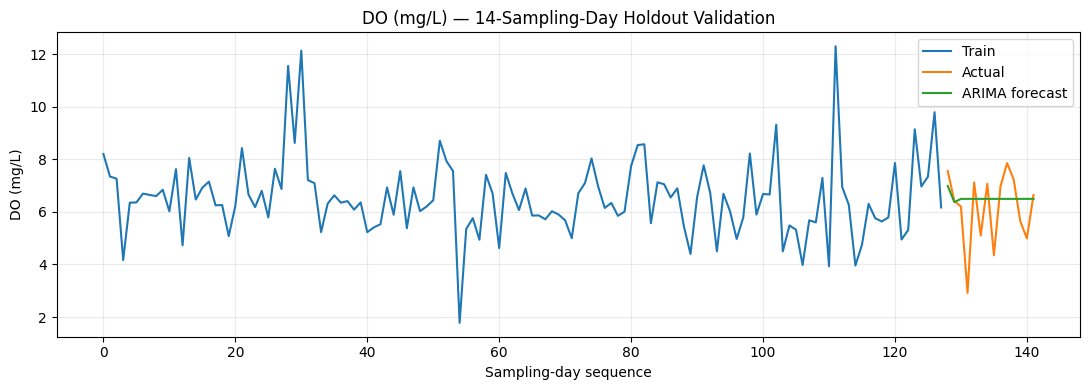

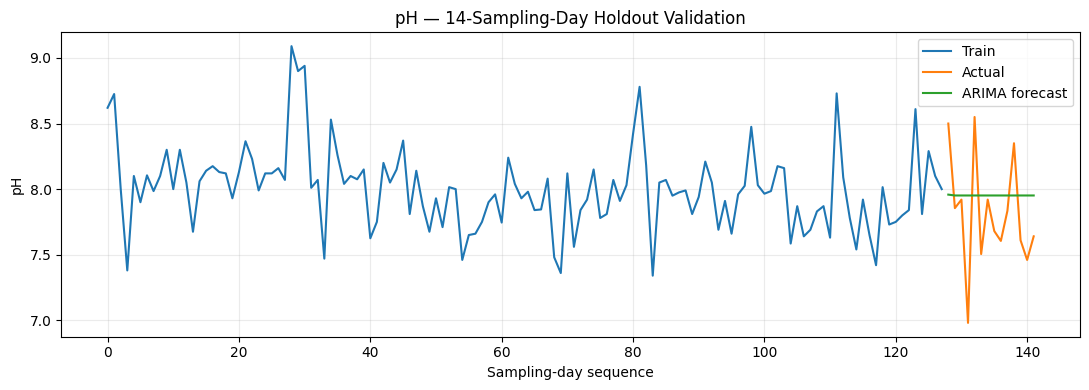

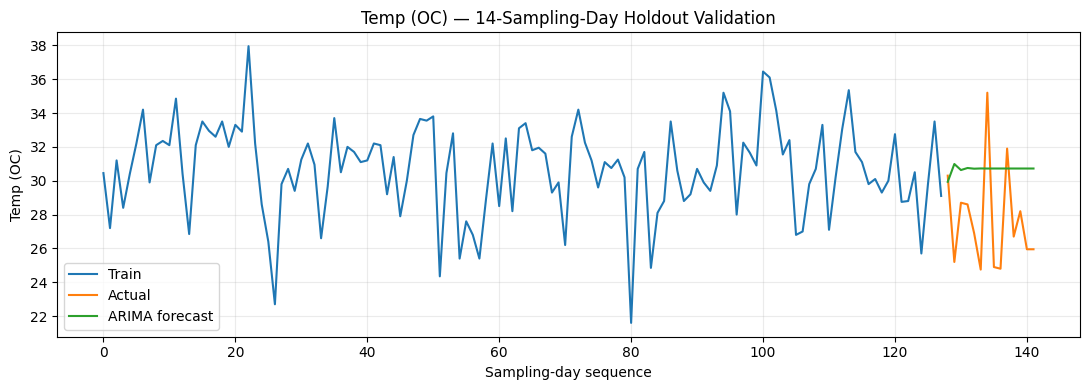

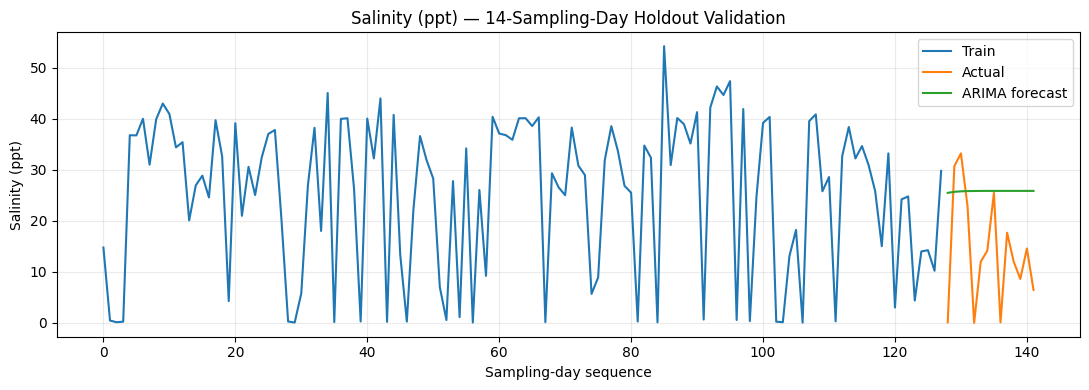

In [13]:
# Plot validation forecasts by observation sequence
for col in PARAM_COLS:
    result = validation_results[col]

    train = result["train"]
    test = result["test"]
    forecast = result["forecast"]

    plt.figure(figsize=(11, 4))
    plt.plot(range(len(train)), train, label="Train")
    plt.plot(range(len(train), len(train) + len(test)), test, label="Actual")
    plt.plot(range(len(train), len(train) + len(forecast)), forecast, label="ARIMA forecast")
    plt.title(f"{col} — 14-Sampling-Day Holdout Validation")
    plt.xlabel("Sampling-day sequence")
    plt.ylabel(col)
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()


## 10. Fit on all data and forecast the next 7 monitoring periods

In [14]:
FORECAST_HORIZON = 7

forecast_rows = {}

for col in PARAM_COLS:
    # Use an equally spaced observation sequence for ARIMA.
    y = daily[col].reset_index(drop=True)

    model = ARIMA(
        y,
        order=orders[col],
        enforce_stationarity=False,
        enforce_invertibility=False,
    ).fit()

    fc = model.get_forecast(steps=FORECAST_HORIZON)
    mean = pd.Series(
        fc.predicted_mean.values,
        index=range(1, FORECAST_HORIZON + 1),
        name=col,
    )
    ci_raw = fc.conf_int()

    forecast_rows[col] = {
        "mean": mean,
        "lower": pd.Series(ci_raw.iloc[:, 0].values, index=mean.index),
        "upper": pd.Series(ci_raw.iloc[:, 1].values, index=mean.index),
    }

forecast_df = pd.DataFrame({
    col: forecast_rows[col]["mean"]
    for col in PARAM_COLS
})
forecast_df.index.name = "forecast_period"

print("Forecasts for the next 7 monitoring periods:")
display(forecast_df.round(3))


Forecasts for the next 7 monitoring periods:


,DO (mg/L),pH,Temp (OC),Salinity (ppt)
forecast_period,,,,
1,6.254,7.815,28.400,16.097
2,6.546,7.830,28.390,16.249
3,6.456,7.830,28.395,16.328
4,6.456,7.830,28.392,16.369
5,6.456,7.830,28.394,16.390
6,6.456,7.830,28.393,16.401
7,6.456,7.830,28.393,16.407


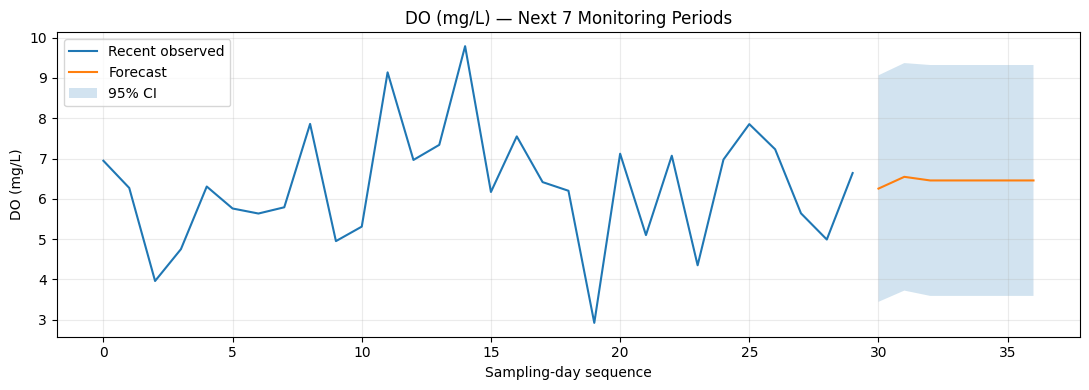

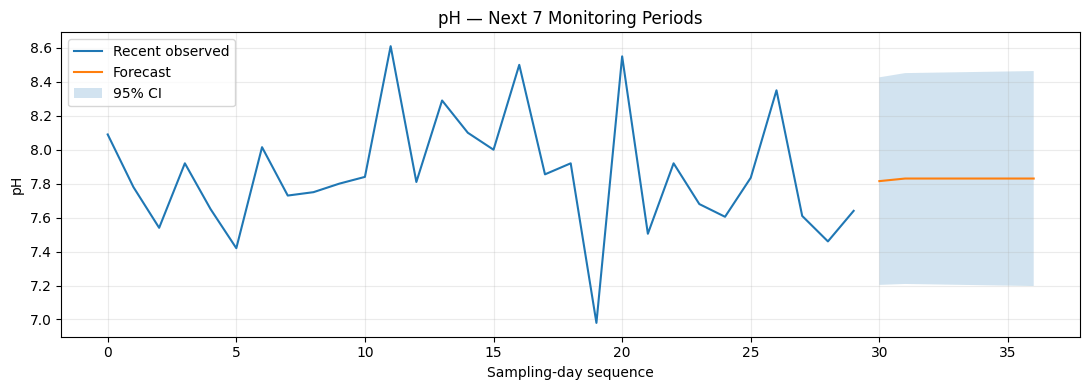

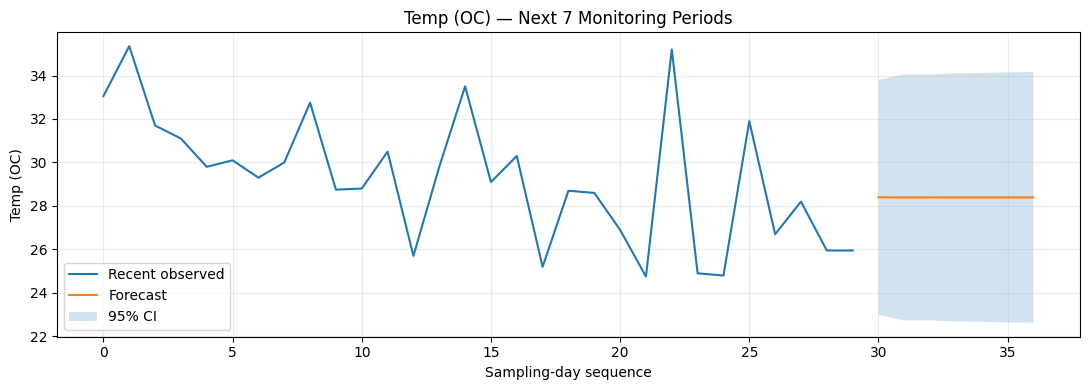

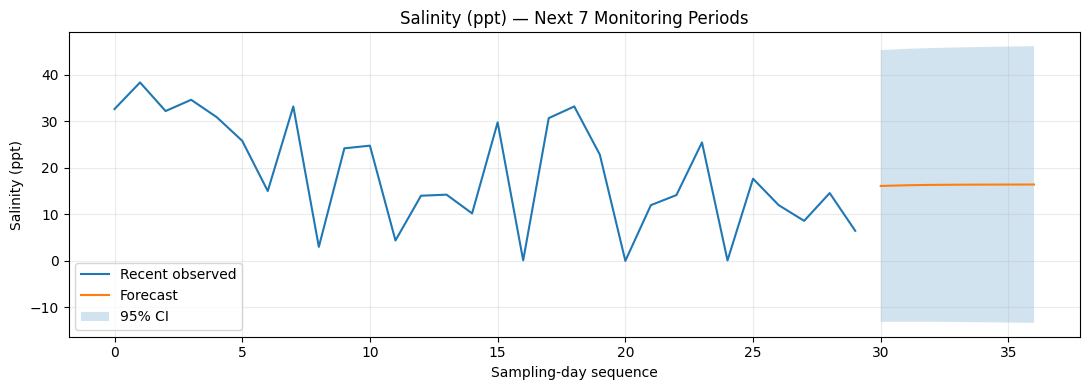

In [15]:
# Plot final forecasts by observation sequence
for col in PARAM_COLS:
    mean = forecast_rows[col]["mean"]
    lower = forecast_rows[col]["lower"]
    upper = forecast_rows[col]["upper"]

    recent = daily[col].reset_index(drop=True).tail(30)

    plt.figure(figsize=(11, 4))
    plt.plot(
        range(len(recent)),
        recent.values,
        label="Recent observed"
    )
    plt.plot(
        range(len(recent), len(recent) + len(mean)),
        mean.values,
        label="Forecast"
    )
    plt.fill_between(
        range(len(recent), len(recent) + len(mean)),
        lower.values,
        upper.values,
        alpha=0.2,
        label="95% CI"
    )
    plt.title(f"{col} — Next {FORECAST_HORIZON} Monitoring Periods")
    plt.xlabel("Sampling-day sequence")
    plt.ylabel(col)
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()


In [17]:
# Save fitted ARIMA models
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

ARIMA_DIR = OUTPUT_DIR / "arima_models"
ARIMA_DIR.mkdir(exist_ok=True)

arima_models = {}

for col in PARAM_COLS:
    y = daily[col].reset_index(drop=True)

    model = ARIMA(
        y,
        order=orders[col],
        enforce_stationarity=False,
        enforce_invertibility=False,
    ).fit()

    arima_models[col] = model

    filename = col.replace(" ", "_").replace("(", "").replace(")", "")
    filename = filename.replace("/", "_")

    model_path = ARIMA_DIR / f"arima_{filename}.joblib"

    joblib.dump(
        {
            "model": model,
            "order": orders[col],
            "parameter": col,
            "training_start": str(daily.index.min()),
            "training_end": str(daily.index.max()),
        },
        model_path
    )

    print(f"Saved: {model_path}")

Saved: outputs\arima_models\arima_DO_mg_L.joblib
Saved: outputs\arima_models\arima_pH.joblib
Saved: outputs\arima_models\arima_Temp_OC.joblib
Saved: outputs\arima_models\arima_Salinity_ppt.joblib


## 11. Convert ARIMA forecasts into projected risk conditions

This step connects the forecasting module to the detection module.

For each forecasted monitoring period:
1. ARIMA predicts DO, pH, Temperature, and Salinity.
2. Each forecasted parameter is assigned Healthy / Conditional / Unhealthy.
3. The composite risk score is calculated.
4. The result is reported as Low / Moderate / High projected environmental risk.

This is a **projected environmental condition**, not a forecast of actual shrimp mortality.


In [18]:
projected = forecast_df.copy()

for col in PARAM_COLS:
    projected[col + " status"] = projected[col].apply(
        lambda x, c=col: parameter_status(x, c)
    )

projected["risk_score"] = projected[
    [c + " status" for c in PARAM_COLS]
].sum(axis=1)

projected["projected_risk"] = np.select(
    [
        projected["risk_score"].between(0, 1),
        projected["risk_score"].between(2, 3),
        projected["risk_score"] >= 4,
    ],
    ["Low", "Moderate", "High"],
    default="Unknown",
)

display(
    projected[
        PARAM_COLS + ["risk_score", "projected_risk"]
    ].round(3)
)


,DO (mg/L),pH,Temp (OC),Salinity (ppt),risk_score,projected_risk
forecast_period,,,,,,
1,6.254,7.815,28.400,16.097,0,Low
2,6.546,7.830,28.390,16.249,0,Low
3,6.456,7.830,28.395,16.328,0,Low
4,6.456,7.830,28.392,16.369,0,Low
5,6.456,7.830,28.394,16.390,0,Low
6,6.456,7.830,28.393,16.401,0,Low
7,6.456,7.830,28.393,16.407,0,Low


In [19]:
# Export forecast and validation outputs
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

forecast_export = projected.reset_index().rename(columns={"index": "forecast_period"})
forecast_export.to_csv(
    OUTPUT_DIR / "water_quality_forecast_and_projected_risk.csv",
    index=False
)

validation_table.to_csv(
    OUTPUT_DIR / "arima_validation_metrics.csv"
)

# Save the trained Random Forest model and feature list.
joblib.dump(
    {
        "model": rf,
        "features": FEATURES,
        "risk_labels": RISK_LABELS,
        "thresholds_description": "Healthy/Conditional/Unhealthy thresholds supplied by the project.",
    },
    OUTPUT_DIR / "random_forest_risk_model.joblib"
)

print("Saved:")
for p in sorted(OUTPUT_DIR.iterdir()):
    print(" -", p)


Saved:
 - outputs\arima_models
 - outputs\arima_validation_metrics.csv
 - outputs\random_forest_risk_model.joblib
 - outputs\water_quality_forecast_and_projected_risk.csv


## NOTE:

### Detection module
What it does:

> A Random Forest classifier was developed to classify water-quality conditions into Low, Moderate, and High environmental risk based on the predefined parameter thresholds. The target classes were generated from a transparent composite risk-scoring scheme derived from dissolved oxygen, pH, temperature, and salinity conditions.

It does not:

> The Random Forest predicts shrimp mortality.

unless the dataset is augmented with verified shrimp mortality/event labels.

### Forecasting module
What it does:

> Individual ARIMA models were developed for dissolved oxygen, pH, temperature, and salinity. The forecasts were subsequently evaluated against the established environmental thresholds to generate projected short-term risk conditions.

### Important limitation
The present dataset supports **water-quality condition detection and forecasting**, but it does not establish a causal or predictive relationship between the measurements and actual shrimp mortality. A stronger mortality-risk model would require labeled mortality events, survival rates, or validated expert risk labels collected at the same time resolution as the environmental measurements.
